<h2>Readability and Unfairness in Terms of Service Documents</h2>
CSE 595 Course Project

Kristine McLaughlin

<h4>1. Data Preprocessing</h4>

In [1]:
import os
import re
import pandas as pd
import numpy as np

In [2]:
# Extract annotated clauses from tagged documents to build dataset
folder_path = 'TaggedDocuments_142'
data = []

for file in os.listdir(folder_path):
    file_path = os.path.join(folder_path, file)
    with open(file_path, "r", encoding="utf-8") as f:
        document_text = f.read()

    # Handling nested tags with a stack
    tag_stack = []
    buffer_text = ""
    clause_start = 0 # index where the clause text starts

    # Get all tags in document (open and close)
    tag_pattern = re.compile(r"<(/?)([a-zA-Z]+)(\d+)>") # <potential backslash, then letters, then a number>
    for tag in tag_pattern.finditer(document_text):
        tag_type = tag.group(1)  # '' for open, '/' for close
        category = tag.group(2)
        num = int(tag.group(3))
        tag_start, tag_end = tag.span() # start is index of tag start <, end is index after >

        # Opening tag - add tag to stack
        if tag_type == "":
            tag_stack.append((category, num))

        # Closing tag
        if tag_type == "/" and (category, num) in tag_stack:
            inner_text = document_text[clause_start:tag_start].strip().lower()

            if inner_text:  # only record if there’s text
                for category, num in tag_stack:
                    data.append({
                        "file_name": file,
                        "category": category,
                        "fairness_score": num,
                        "text": inner_text
                    })

            # Remove the matching tag from the stack
            if tag_stack and tag_stack[-1] == (category, num):
                tag_stack.pop()
            else:
                # Handle mismatched nesting by removing first occurrence
                if (category, num) in tag_stack:
                    tag_stack.remove((category, num))
        
        # Update where the text (should) start
        clause_start = tag_end

# Turn array into df
data = pd.DataFrame(data, columns=["file_name", "category", "fairness_score", "text"])
print(f"Extracted {len(data)} annotated clauses from {len(os.listdir(folder_path))} files")
print(data.head())

Extracted 3554 annotated clauses from 142 files
        file_name category  fairness_score  \
0  MyHeritage.xml      use               2   
1  MyHeritage.xml      use               2   
2  MyHeritage.xml       ch               2   
3  MyHeritage.xml      use               2   
4  MyHeritage.xml       cr               2   

                                                text  
0  please read them carefully, because by using t...  
1  if you do not agree with any provision in this...  
2  we reserve the right to modify any provision h...  
3  you agree to be bound to any changes to this a...  
4  we will not edit or monitor user-provided cont...  


In [3]:
# Manual check: Save to csv to investigate
data.to_csv("data.csv", index=False)

In [4]:
# Remove entries with fairness score of 4
data = data[data['fairness_score'] != 4]

In [5]:
# Get statistics on data
data.describe()

,fairness_score
count,3546.000000
mean,2.143542
std,0.463000
min,1.000000
25%,2.000000
50%,2.000000
75%,2.000000
max,3.000000


In [6]:
data['fairness_score'].value_counts()

fairness_score
2    2713
3     671
1     162
Name: count, dtype: int64

In [7]:
# First testing dataset just be the clearly fair (1) and clearly unfair (3) clauses
clear_fair = data[data['fairness_score'] == 1]
clear_unfair = data[data['fairness_score'] == 3]
data_clear = pd.concat([clear_fair, clear_unfair])

# Add binary fair/unfair value. 0 = fair, 1 = unfair
data_clear['unfair'] = (data_clear['fairness_score'] == 3).astype(int)

In [8]:
data_clear.describe()

,fairness_score,unfair
count,833.000000,833.000000
mean,2.611044,0.805522
std,0.792072,0.396036
min,1.000000,0.000000
25%,3.000000,1.000000
50%,3.000000,1.000000
75%,3.000000,1.000000
max,3.000000,1.000000


In [9]:
data_clear['unfair'].value_counts()

unfair
1    671
0    162
Name: count, dtype: int64

In [10]:
data_clear.head()

,file_name,category,fairness_score,text,unfair
57,Spotify.xml,ltd,1,nothing in the agreements removes or limits sp...,0
98,Xoom.xml,ltd,1,"paypal and you acknowledge that paypal, not ap...",0
150,Kardia.xml,ltd,1,"furthermore, nothing in these terms limits or ...",0
151,Kardia.xml,ltd,1,alivecor will be excused from performance unde...,0
154,Kardia.xml,j,1,"if you are a consumer located in the eu, such ...",0


<h4>2. Calculate Baselines</h4>

In [11]:
import textstat
import matplotlib.pyplot as plt

In [12]:
# Baseline 1: Random performance. Putting on scale of Flesch Reading Ease, 0-100
readability_baselines = data_clear.copy()
readability_baselines['random'] = np.random.uniform(0, 100, size=len(readability_baselines))
readability_baselines.head()

,file_name,category,fairness_score,text,unfair,random
57,Spotify.xml,ltd,1,nothing in the agreements removes or limits sp...,0,42.716481
98,Xoom.xml,ltd,1,"paypal and you acknowledge that paypal, not ap...",0,2.382924
150,Kardia.xml,ltd,1,"furthermore, nothing in these terms limits or ...",0,55.738590
151,Kardia.xml,ltd,1,alivecor will be excused from performance unde...,0,37.645499
154,Kardia.xml,j,1,"if you are a consumer located in the eu, such ...",0,3.601360


In [13]:
# Baseline 2: Traditional readability metrics
# Flesch Reading Ease, Flesch-Kincaid Grade Level, and Gunning Fog Index
def get_readability_scores(clause):
    flesch_ease = textstat.flesch_reading_ease(clause) # 0-100. Higher = easier
    flesch_kincaid = textstat.flesch_kincaid_grade(clause) # 0-~20. US grade level required. Higher = more difficult
    gunning_fog = textstat.gunning_fog(clause) # 0-~20. Years of education needed. Higher = more difficult
    
    return pd.Series({
        "flesch_ease": flesch_ease,
        "fk_grade": flesch_kincaid,
        "gunning_fog": gunning_fog
    })

In [14]:
# Apply function to the text column and create new df with those scores
scores = readability_baselines["text"].apply(get_readability_scores)
readability_baselines = pd.concat([readability_baselines, scores], axis=1)
readability_baselines.head()

,file_name,category,fairness_score,text,unfair,random,flesch_ease,fk_grade,gunning_fog
57,Spotify.xml,ltd,1,nothing in the agreements removes or limits sp...,0,42.716481,2.365517,20.133793,26.772414
98,Xoom.xml,ltd,1,"paypal and you acknowledge that paypal, not ap...",0,2.382924,-22.537857,33.792857,38.857143
150,Kardia.xml,ltd,1,"furthermore, nothing in these terms limits or ...",0,55.738590,16.496667,17.665926,21.170370
151,Kardia.xml,ltd,1,alivecor will be excused from performance unde...,0,37.645499,37.220000,18.005000,22.000000
154,Kardia.xml,j,1,"if you are a consumer located in the eu, such ...",0,3.601360,46.945000,11.680000,16.000000


In [15]:
# Investigate statistics on overall readability of dataset
readability_baselines.describe()

,fairness_score,unfair,random,flesch_ease,fk_grade,gunning_fog
count,833.000000,833.000000,833.000000,833.000000,833.000000,833.000000
mean,2.611044,0.805522,49.858960,26.145128,18.811845,21.862297
std,0.792072,0.396036,28.778501,29.469979,9.559456,10.143707
min,1.000000,0.000000,0.031622,-223.943436,2.470000,4.000000
25%,3.000000,1.000000,24.677721,11.130000,12.627143,15.485714
50%,3.000000,1.000000,50.700330,28.620690,16.674194,19.955556
75%,3.000000,1.000000,75.037543,45.000000,22.725000,26.130612
max,3.000000,1.000000,99.966893,95.688182,108.837761,114.565251


In [16]:
# Sort for visualization
baselines_sorted = readability_baselines.sort_values(by='flesch_ease', ascending=True)
baselines_sorted.head()

,file_name,category,fairness_score,text,unfair,random,flesch_ease,fk_grade,gunning_fog
2550,Bookingcom.xml,ltd,3,"however and to the extent permitted by law, ne...",1,40.470732,-223.943436,108.837761,114.565251
1155,Airbnb.xml,ltd,3,neither airbnb nor any other party involved in...,1,8.674185,-131.135000,78.254468,83.497872
1470,Crowdtangle.xml,ltd,3,with the exception of any acts or omissions of...,1,78.880943,-128.856429,72.968095,78.152381
3087,WeChat.xml,a,3,except to the extent that: (a) any applicable ...,1,15.312175,-102.207000,64.779333,69.600000
2841,VisaCashback.xml,j,1,"if you are a resident of (i) argentina, brazil...",0,83.354701,-84.437273,60.561818,65.032168


In [17]:
# Examining clause rated most unreadable across all baselines
baselines_sorted.iloc[0]['text']

'however and to the extent permitted by law, neither we nor any of our officers, directors, employees, representatives, subsidiaries, affiliated companies, distributors, affiliate (distribution) partners, licensees, agents or others involved in creating, sponsoring, promoting, or otherwise making available the site and its contents shall be liable for (i) any punitive, special, indirect or consequential loss or damages, any loss of production, loss of profit, loss of revenue, loss of contract, loss of or damage to goodwill or reputation, loss of claim, (ii) any inaccuracy relating to the (descriptive) information (including rates, availability and ratings) of the supplier as made available on our platform, (iii) the services rendered or the products offered by the supplier or other business partners, (iv) any (direct, indirect, consequential or punitive) damages, losses or costs suffered, incurred or paid by you, pursuant to, arising out of or in connection with the use, inability to u

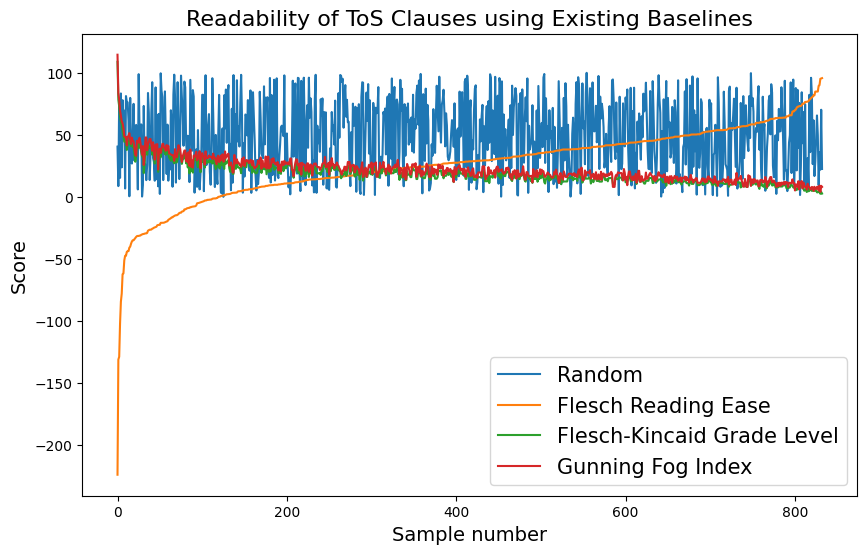

In [18]:
# Generate plot to visualize baseline trend
x = list(range(0, len(baselines_sorted)))
plt.figure(figsize=(10, 6))
plt.plot(x, baselines_sorted['random'].tolist(), label='Random')
plt.plot(x, baselines_sorted['flesch_ease'].tolist(), label='Flesch Reading Ease')
plt.plot(x, baselines_sorted['fk_grade'].tolist(), label='Flesch-Kincaid Grade Level')
plt.plot(x, baselines_sorted['gunning_fog'].tolist(), label='Gunning Fog Index')

plt.xlabel('Sample number', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Readability of ToS Clauses using Existing Baselines', fontsize=16)

plt.legend(fontsize=15)
plt.show()

Graph visualization with highest 752 samples for Flesch Reading Ease


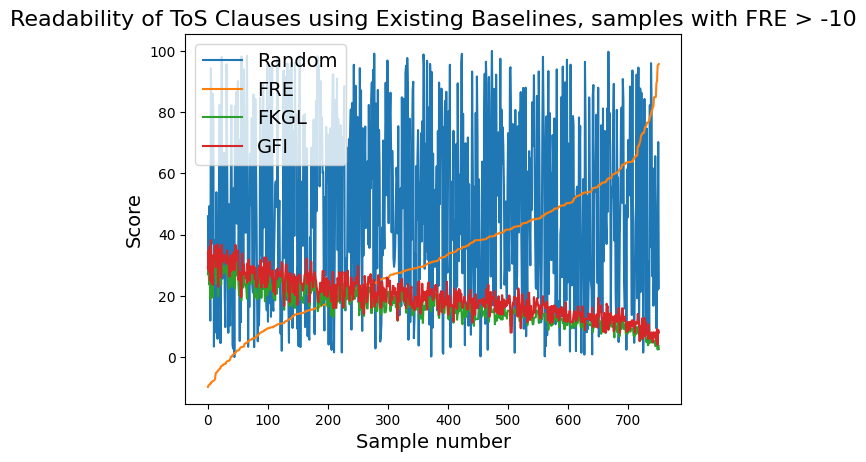

In [19]:
# Remove extreme samples to better visualize trend for majority of graph
baseline_cropped = baselines_sorted[baselines_sorted['flesch_ease'] > -10]

x = list(range(0, len(baseline_cropped)))
print("Graph visualization with highest", len(baseline_cropped), "samples for Flesch Reading Ease")
plt.plot(x, baseline_cropped['random'].tolist(), label='Random')
plt.plot(x, baseline_cropped['flesch_ease'].tolist(), label='FRE')
plt.plot(x, baseline_cropped['fk_grade'].tolist(), label='FKGL')
plt.plot(x, baseline_cropped['gunning_fog'].tolist(), label='GFI')

plt.xlabel('Sample number', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Readability of ToS Clauses using Existing Baselines, samples with FRE > -10', fontsize=16)

plt.legend(fontsize=14)
plt.show()

<h4>3. New Readability Score Implementation</h4>

In [20]:
import spacy
from transformers import GPT2TokenizerFast, GPT2LMHeadModel
import torch
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
# Load in NLP English model, calculates features like POS tags and dependency labels for us. Using small model
nlp_model = spacy.load("en_core_web_sm")

In [22]:
def get_linguistic_features(text):
    doc = nlp_model(text)
    tokens = [t for t in doc if not t.is_space]
    words = [t for t in tokens if t.is_alpha]

    # Average sentence length and average word length
    num_tokens = len(tokens)
    num_words = len(words) # if len(words)>0 else 0.0001
    num_sents = len(list(doc.sents)) # max(1, len(list(doc.sents)))
    
    avg_sent_len = num_tokens / num_sents # Avg number of words in a sent
    avg_word_len = (sum(len(t.text) for t in words) / num_words) if num_words else 0

    # POS ratios
    pos_counts = doc.count_by(spacy.attrs.POS)
    vocab = doc.vocab
    def pos_ratio(tag):
        key = vocab.strings[tag]
        return pos_counts.get(key, 0) / num_tokens if num_tokens else 0
    noun_ratio = pos_ratio("NOUN")
    verb_ratio = pos_ratio("VERB")
    adj_ratio  = pos_ratio("ADJ")

    # Dependency tree depth
    sent_depths = []
    for sent in doc.sents:
        depths = []
        for token in sent:
            depth = 0
            head = token
            while head.head != head:
                depth += 1
                head = head.head
            depths.append(depth)
        if depths:
            sent_depths.append(max(depths))
    # avg_tree_depth = np.mean(sent_depths) if sent_depths else 0
    max_tree_depth = np.max(sent_depths) if sent_depths else 0

    # Readability formulas
    fre = textstat.flesch_reading_ease(text)
    fog = textstat.gunning_fog(text)

    return {
        "avg_sent_len": avg_sent_len,
        "avg_word_len": avg_word_len,
        "noun_ratio": noun_ratio,
        "verb_ratio": verb_ratio,
        "adj_ratio": adj_ratio,
        "fre": fre,
        "fog": fog,
        "tree_depth": max_tree_depth
    }

In [23]:
# Using GPT2 to measure LLM perplexity
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
gpt2.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [24]:
# Calculate average surprisal using GPT 2
def get_avg_surprisal(text, max_length=512):
    tokens = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
    with torch.no_grad():
        outputs = gpt2(**tokens, labels=tokens["input_ids"])
        # outputs.loss is average negative log-likelihood per token, GPT2 uses CrossEntropyLoss 
        return float(outputs.loss)

In [25]:
# Calculate linguistic features and surprisal, add all features to dataframe
# Text to compute the features on should be df[text_col]
def compute_all_features(df, text_col):
    # Linguistic features
    ling_features = []
    for text in tqdm(df[text_col].astype(str).tolist(), desc="linguistic features"):
        ling_features.append(get_linguistic_features(text))
    feature_df = pd.DataFrame(ling_features)

    # Surprisal
    surprisal_vals = []
    for text in tqdm(df[text_col].astype(str).tolist(), desc="llm surprisal"):
        surprisal_vals.append(get_avg_surprisal(text))
    feature_df["surprisal"] = surprisal_vals

    # Combine original df with features
    return pd.concat([df.reset_index(drop=True), feature_df.reset_index(drop=True)], axis=1)

In [26]:
feature_df = compute_all_features(readability_baselines, "text")
feature_df.head()

llm surprisal: 100%|██████████| 833/833 [01:04<00:00, 12.97it/s]


,file_name,category,fairness_score,text,unfair,random,flesch_ease,fk_grade,gunning_fog,avg_sent_len,avg_word_len,noun_ratio,verb_ratio,adj_ratio,fre,fog,tree_depth,surprisal
0,Spotify.xml,ltd,1,nothing in the agreements removes or limits sp...,0,42.716481,2.365517,20.133793,26.772414,36.0,5.965517,0.277778,0.111111,0.111111,2.365517,26.772414,7,4.103014
1,Xoom.xml,ltd,1,"paypal and you acknowledge that paypal, not ap...",0,2.382924,-22.537857,33.792857,38.857143,90.0,5.236111,0.222222,0.133333,0.066667,-22.537857,38.857143,16,2.641172
2,Kardia.xml,ltd,1,"furthermore, nothing in these terms limits or ...",0,55.738590,16.496667,17.665926,21.170370,31.0,5.071429,0.225806,0.096774,0.064516,16.496667,21.170370,9,3.827645
3,Kardia.xml,ltd,1,alivecor will be excused from performance unde...,0,37.645499,37.220000,18.005000,22.000000,43.0,4.575000,0.232558,0.093023,0.046512,37.220000,22.000000,10,3.278575
4,Kardia.xml,j,1,"if you are a consumer located in the eu, such ...",0,3.601360,46.945000,11.680000,16.000000,24.0,4.380952,0.125000,0.041667,0.166667,46.945000,16.000000,6,4.816319


In [27]:
feature_df.describe()

,fairness_score,unfair,random,flesch_ease,fk_grade,gunning_fog,avg_sent_len,avg_word_len,noun_ratio,verb_ratio,adj_ratio,fre,fog,tree_depth,surprisal
count,833.000000,833.000000,833.000000,833.000000,833.000000,833.000000,833.000000,833.000000,833.000000,833.000000,833.000000,833.000000,833.000000,833.000000,833.000000
mean,2.611044,0.805522,49.858960,26.145128,18.811845,21.862297,44.826531,4.856895,0.229670,0.099845,0.056098,26.145128,21.862297,8.769508,3.322225
std,0.792072,0.396036,28.778501,29.469979,9.559456,10.143707,31.057410,0.474395,0.057407,0.041114,0.042335,29.469979,10.143707,3.751561,0.701224
min,1.000000,0.000000,0.031622,-223.943436,2.470000,4.000000,7.000000,3.250000,0.045455,0.000000,0.000000,-223.943436,4.000000,2.000000,1.676566
25%,3.000000,1.000000,24.677721,11.130000,12.627143,15.485714,26.000000,4.533333,0.192982,0.071429,0.027778,11.130000,15.485714,6.000000,2.822982
50%,3.000000,1.000000,50.700330,28.620690,16.674194,19.955556,36.000000,4.833333,0.228814,0.095238,0.050000,28.620690,19.955556,8.000000,3.257061
75%,3.000000,1.000000,75.037543,45.000000,22.725000,26.130612,55.000000,5.142857,0.264151,0.125000,0.080000,45.000000,26.130612,11.000000,3.752290
max,3.000000,1.000000,99.966893,95.688182,108.837761,114.565251,355.000000,7.142857,0.411765,0.259259,0.280000,95.688182,114.565251,30.000000,6.184317


In [51]:
# Curious about surprisal
pd.options.display.float_format = '{:.4f}'.format
feature_df['surprisal'].describe()

count   833.0000
mean      3.3222
std       0.7012
min       1.6766
25%       2.8230
50%       3.2571
75%       3.7523
max       6.1843
Name: surprisal, dtype: float64

In [55]:
# Curious about which text has the highest surprisal
max_row = feature_df.loc[feature_df['surprisal'].idxmax()]
print(max_row)
print("Full text:", max_row['text'])

file_name                                                  Snap.xml
category                                                          j
fairness_score                                                    3
text              you and snap group limited consent to the excl...
unfair                                                            1
random                                                      53.8857
flesch_ease                                                 56.9785
fk_grade                                                     8.5415
gunning_fog                                                 14.4308
avg_sent_len                                                14.0000
avg_word_len                                                 5.2308
noun_ratio                                                   0.2857
verb_ratio                                                   0.0714
adj_ratio                                                    0.1429
fre                                             

In [56]:
# Curious about which text has the lowest surprisal
min_row = feature_df.loc[feature_df['surprisal'].idxmin()]
print(min_row)
print("Full text:", min_row['text'])

file_name                                                   Box.xml
category                                                        ter
fairness_score                                                    3
text              we reserve the right to suspend or terminate y...
unfair                                                            1
random                                                      55.4314
flesch_ease                                                 59.6350
fk_grade                                                     9.9100
gunning_fog                                                 12.0000
avg_sent_len                                                21.0000
avg_word_len                                                 4.3500
noun_ratio                                                   0.2381
verb_ratio                                                   0.1429
adj_ratio                                                    0.0476
fre                                             

In [28]:
# Build composite readability score. Using PCA
def build_composite_score(df):
    features = df[["avg_sent_len", "avg_word_len", "noun_ratio", "verb_ratio", "adj_ratio", "fre", "fog", "tree_depth", "surprisal"]].copy()
    
    # Fill any missing values with median
    features = features.fillna(features.median())

    # Have to standardize because PCA sensitive to magnitudes
    scaler = StandardScaler()
    features = scaler.fit_transform(features)

    # Weighted combination of top 3 PCs
    pca = PCA(n_components=3)
    pcs = pca.fit_transform(features)
    explained = pca.explained_variance_ratio_
    pca_weighted_sum = (pcs * explained).sum(axis=1)

    # Add score to dataframe
    df["readability"] = pca_weighted_sum
    return df, {"scaler": scaler, "pca": pca}


In [29]:
feature_df, model = build_composite_score(feature_df)
feature_df.head()

,file_name,category,fairness_score,text,unfair,random,flesch_ease,fk_grade,gunning_fog,avg_sent_len,avg_word_len,noun_ratio,verb_ratio,adj_ratio,fre,fog,tree_depth,surprisal,readability
0,Spotify.xml,ltd,1,nothing in the agreements removes or limits sp...,0,42.716481,2.365517,20.133793,26.772414,36.0,5.965517,0.277778,0.111111,0.111111,2.365517,26.772414,7,4.103014,0.976311
1,Xoom.xml,ltd,1,"paypal and you acknowledge that paypal, not ap...",0,2.382924,-22.537857,33.792857,38.857143,90.0,5.236111,0.222222,0.133333,0.066667,-22.537857,38.857143,16,2.641172,1.289198
2,Kardia.xml,ltd,1,"furthermore, nothing in these terms limits or ...",0,55.738590,16.496667,17.665926,21.170370,31.0,5.071429,0.225806,0.096774,0.064516,16.496667,21.170370,9,3.827645,0.168253
3,Kardia.xml,ltd,1,alivecor will be excused from performance unde...,0,37.645499,37.220000,18.005000,22.000000,43.0,4.575000,0.232558,0.093023,0.046512,37.220000,22.000000,10,3.278575,-0.204543
4,Kardia.xml,j,1,"if you are a consumer located in the eu, such ...",0,3.601360,46.945000,11.680000,16.000000,24.0,4.380952,0.125000,0.041667,0.166667,46.945000,16.000000,6,4.816319,-0.337242


In [30]:
pd.options.display.float_format = '{:.4f}'.format
feature_df['readability'].describe()

count   833.0000
mean      0.0000
std       0.7895
min      -2.2303
25%      -0.4722
50%      -0.0509
75%       0.3965
max       6.2207
Name: readability, dtype: float64

In [31]:
# Confirming if higher readability score means more complex, also interesting statistic
corr = feature_df["readability"].corr(feature_df["gunning_fog"])
print("Correlation with Gunning Fog:", corr)

Correlation with Gunning Fog: 0.8802064727401623


In [32]:
# Inspect info from PCA
loadings = pd.Series(
    model["pca"].components_[0],
    index=["avg_sent_len", "avg_word_len", "noun_ratio", "verb_ratio", "adj_ratio", "fre", "fog", "tree_depth", "surprisal"]
)

loadings = loadings.sort_values()
print(loadings)

fre            -0.4986
surprisal      -0.1835
verb_ratio     -0.1348
adj_ratio       0.0958
noun_ratio      0.1163
avg_word_len    0.1646
tree_depth      0.4056
avg_sent_len    0.4765
fog             0.5080
dtype: float64


In [33]:
pca = model["pca"]
feature_names = ["avg_sent_len", "avg_word_len", "noun_ratio", "verb_ratio", 
                 "adj_ratio", "fre", "fog", "tree_depth", "surprisal"]

for i, component in enumerate(pca.components_):
    loadings = pd.Series(component, index=feature_names)
    print(f"PC{i+1} loadings:")
    print(loadings.sort_values())
    print()
    
# Explained variance ratio
print("Explained variance ratio per PC:")
print(pca.explained_variance_ratio_)

PC1 loadings:
fre            -0.4986
surprisal      -0.1835
verb_ratio     -0.1348
adj_ratio       0.0958
noun_ratio      0.1163
avg_word_len    0.1646
tree_depth      0.4056
avg_sent_len    0.4765
fog             0.5080
dtype: float64

PC2 loadings:
verb_ratio     -0.3264
avg_sent_len   -0.1973
tree_depth     -0.1373
fre            -0.0660
fog            -0.0581
noun_ratio      0.4101
surprisal       0.4182
adj_ratio       0.4287
avg_word_len    0.5487
dtype: float64

PC3 loadings:
noun_ratio     -0.4014
fre            -0.2117
tree_depth     -0.0619
adj_ratio      -0.0109
avg_sent_len    0.0275
fog             0.1222
avg_word_len    0.3704
surprisal       0.4231
verb_ratio      0.6768
dtype: float64

Explained variance ratio per PC:
[0.39080849 0.19706148 0.12240712]


In [34]:
results_sorted = feature_df.sort_values(by='flesch_ease', ascending=True)

In [49]:
# Examining clause rated most unreadable across all baselines
print(baselines_sorted.iloc[0])
print("Text: ", baselines_sorted.iloc[0]["text"])

file_name                                            Bookingcom.xml
category                                                        ltd
fairness_score                                                    3
text              however and to the extent permitted by law, ne...
unfair                                                            1
random                                                      40.4707
flesch_ease                                               -223.9434
fk_grade                                                   108.8378
gunning_fog                                                114.5653
Name: 2550, dtype: object
Text:  however and to the extent permitted by law, neither we nor any of our officers, directors, employees, representatives, subsidiaries, affiliated companies, distributors, affiliate (distribution) partners, licensees, agents or others involved in creating, sponsoring, promoting, or otherwise making available the site and its contents shall be liable for (i

In [50]:
# Examining clause rated most unreadable with my readability
print(results_sorted.iloc[0])
print("Text: ", results_sorted.iloc[0]["text"])

file_name                                            Bookingcom.xml
category                                                        ltd
fairness_score                                                    3
text              however and to the extent permitted by law, ne...
unfair                                                            1
random                                                      40.4707
flesch_ease                                               -223.9434
fk_grade                                                   108.8378
gunning_fog                                                114.5653
avg_sent_len                                               355.0000
avg_word_len                                                 5.5385
noun_ratio                                                   0.2563
verb_ratio                                                   0.0704
adj_ratio                                                    0.0958
fre                                             

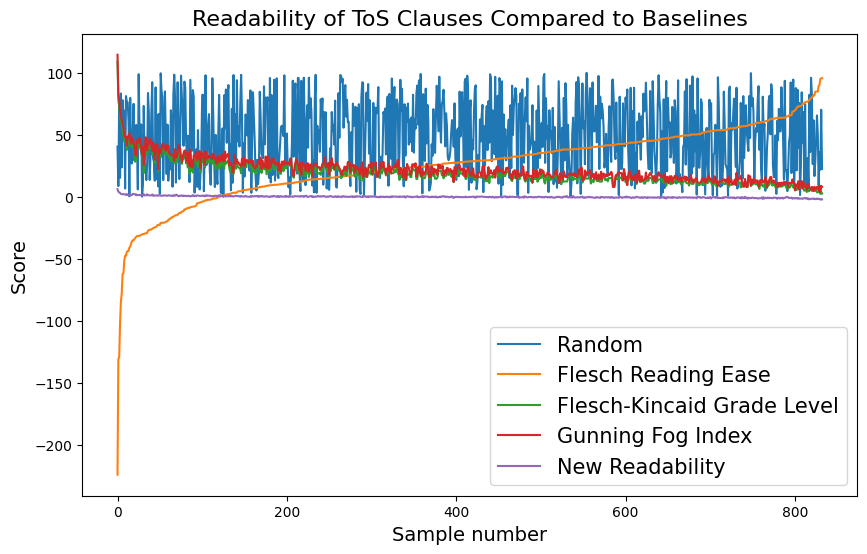

In [35]:
# Generate plot to visualize results
x = list(range(0, len(results_sorted)))
plt.figure(figsize=(10, 6))
plt.plot(x, results_sorted['random'].tolist(), label='Random')
plt.plot(x, results_sorted['flesch_ease'].tolist(), label='Flesch Reading Ease')
plt.plot(x, results_sorted['fk_grade'].tolist(), label='Flesch-Kincaid Grade Level')
plt.plot(x, results_sorted['gunning_fog'].tolist(), label='Gunning Fog Index')
plt.plot(x, results_sorted['readability'].tolist(), label='New Readability')

plt.xlabel('Sample number', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Readability of ToS Clauses Compared to Baselines', fontsize=16)

plt.legend(fontsize=15)
plt.show()

Graph visualization with highest 752 samples for Flesch Reading Ease


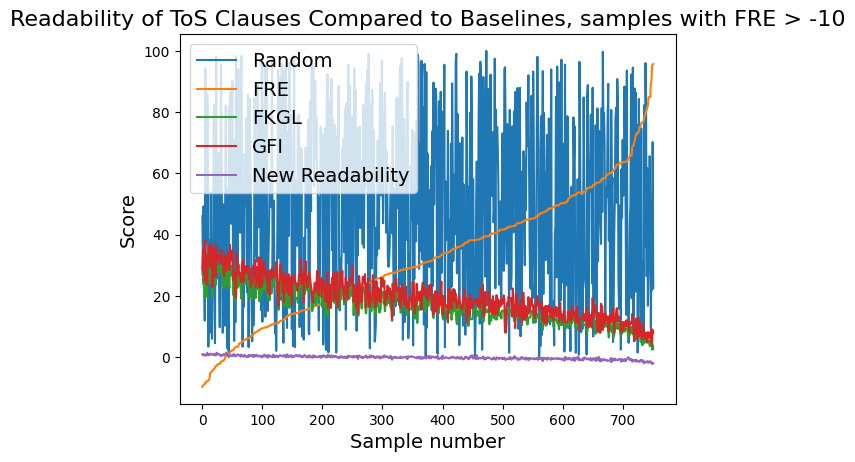

In [42]:
# Remove extreme samples to better visualize trend for majority of graph
results_cropped = results_sorted[results_sorted['flesch_ease'] > -10]

x = list(range(0, len(results_cropped)))
print("Graph visualization with highest", len(results_cropped), "samples for Flesch Reading Ease")
plt.plot(x, results_cropped['random'].tolist(), label='Random')
plt.plot(x, results_cropped['flesch_ease'].tolist(), label='FRE')
plt.plot(x, results_cropped['fk_grade'].tolist(), label='FKGL')
plt.plot(x, results_cropped['gunning_fog'].tolist(), label='GFI')
plt.plot(x, results_cropped['readability'].tolist(), label='New Readability')

plt.xlabel('Sample number', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Readability of ToS Clauses Compared to Baselines, samples with FRE > -10', fontsize=16)

plt.legend(fontsize=14)
plt.show()

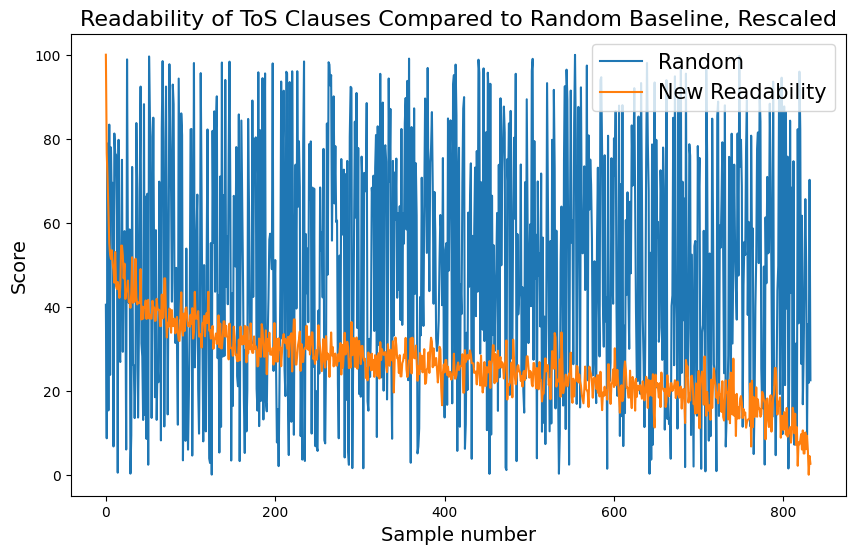

In [60]:
# Rescale readability score to FRE bounds (0-100) to compare to random baseline. Min-max normalization
results_sorted["readability_scaled"] = (
    (results_sorted["readability"] - results_sorted["readability"].min()) /
    (results_sorted["readability"].max() - results_sorted["readability"].min())
) * 100

x = list(range(0, len(results_sorted)))
plt.figure(figsize=(10, 6))
plt.plot(x, results_sorted['random'].tolist(), label='Random')
plt.plot(x, results_sorted['readability_scaled'].tolist(), label='New Readability')

plt.xlabel('Sample number', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Readability of ToS Clauses Compared to Random Baseline, Rescaled', fontsize=16)

plt.legend(fontsize=15)
plt.show()

<h4>4. Investigate Correlation</h4>

In [36]:
from scipy.stats import pointbiserialr

corr, p_value = pointbiserialr(feature_df['unfair'], feature_df['readability'])
print(f"Point-biserial correlation: {corr:.3f}, p-value: {p_value:.3g}")

Point-biserial correlation: -0.077, p-value: 0.0271


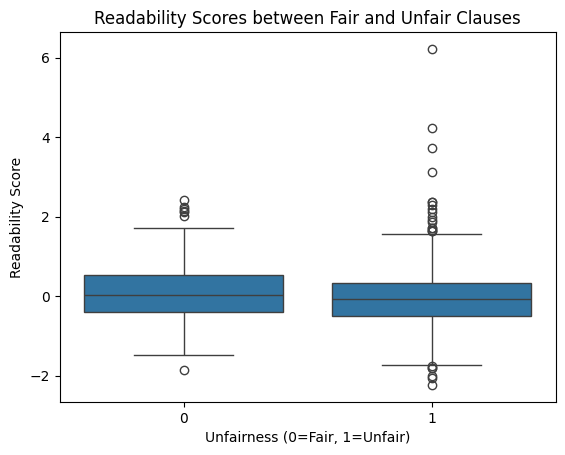

In [37]:
import seaborn as sns

sns.boxplot(x='unfair', y='readability', data=feature_df)
plt.xlabel("Unfairness (0=Fair, 1=Unfair)")
plt.ylabel("Readability Score")
plt.title("Readability Scores between Fair and Unfair Clauses")
plt.show()

In [57]:
corr, p_value = pointbiserialr(feature_df['unfair'], feature_df['gunning_fog'])
print(f"Point-biserial correlation: {corr:.3f}, p-value: {p_value:.3g}")

Point-biserial correlation: -0.042, p-value: 0.228


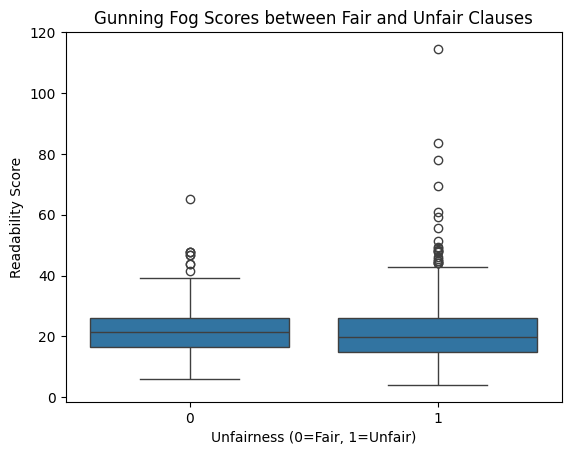

In [38]:
import seaborn as sns

sns.boxplot(x='unfair', y='gunning_fog', data=feature_df)
plt.xlabel("Unfairness (0=Fair, 1=Unfair)")
plt.ylabel("Readability Score")
plt.title("Gunning Fog Scores between Fair and Unfair Clauses")
plt.show()

In [64]:
# Correlation with other readability metrics
corr, p_value = pointbiserialr(feature_df['unfair'], feature_df['fk_grade'])
print(f"Point-biserial correlation: {corr:.3f}, p-value: {p_value:.3g}")

corr, p_value = pointbiserialr(feature_df['unfair'], feature_df['fre'])
print(f"Point-biserial correlation: {corr:.3f}, p-value: {p_value:.3g}")

Point-biserial correlation: -0.000, p-value: 0.992
Point-biserial correlation: 0.032, p-value: 0.354
